# ex019_Splitting_KineticDecay1D

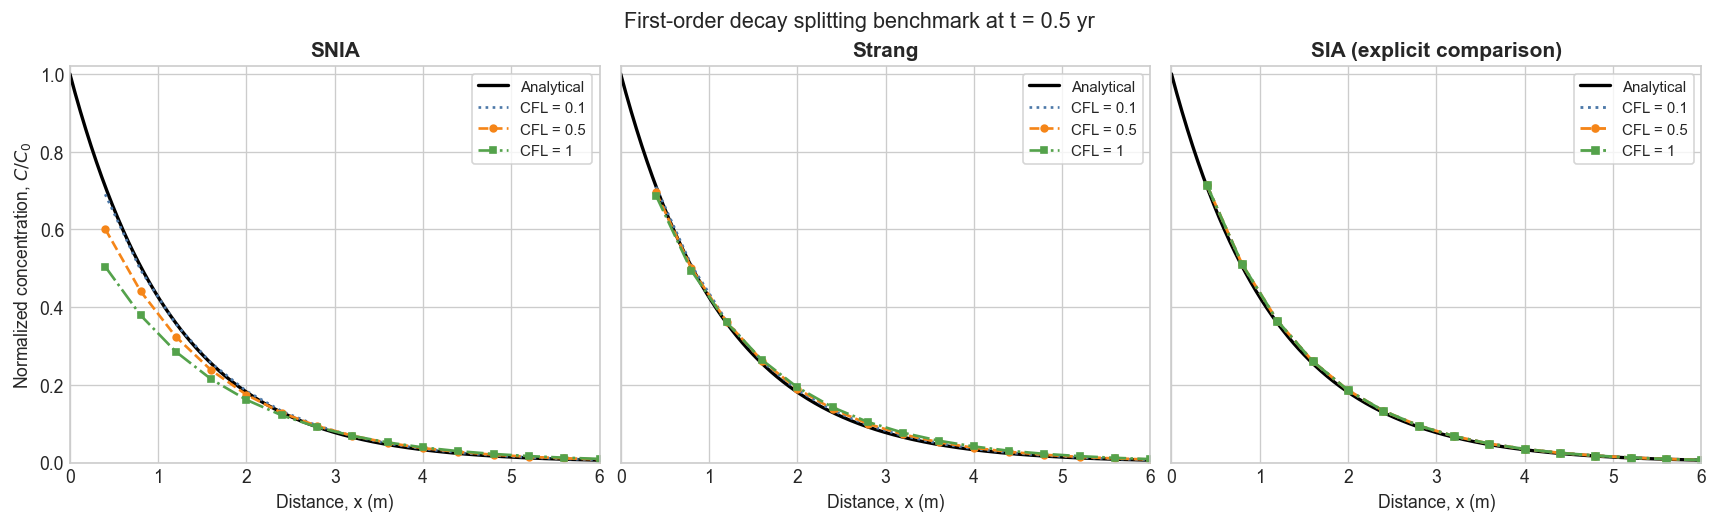

,method,cfl,logical_steps,damkohler_per_step,paper_node_rmse,cell_center_rmse,boundary_endpoint_concentration,transport_solves,reaction_evaluations,wall_time_seconds
0,SIA,0.1,1250,0.04,0.003375,0.043735,1.0,7500,7500,18.440806
1,SIA,0.5,250,0.20,0.003375,0.043735,1.0,2792,2792,5.838295
2,SIA,1.0,125,0.40,0.003375,0.043735,1.0,2455,2455,4.200004
3,SNIA,0.1,1250,0.04,0.006163,0.036515,1.0,1250,1250,4.792460
4,SNIA,0.5,250,0.20,0.034467,0.013871,1.0,250,250,2.898428
5,SNIA,1.0,125,0.40,0.066425,0.029011,1.0,125,125,2.422488
6,Strang,0.1,1250,0.04,0.003460,0.042746,1.0,2500,1250,6.697572
7,Strang,0.5,250,0.20,0.006762,0.040039,1.0,500,250,3.233068
8,Strang,1.0,125,0.40,0.010604,0.039097,1.0,250,125,2.606959


In [1]:
from pathlib import Path

CASE_DIR = Path.cwd()
OUTPUT_DIR = CASE_DIR / "output"
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {"figure.dpi": 120, "savefig.dpi": 240, "font.size": 10.5, "axes.titleweight": "bold"}
)
with np.load(OUTPUT_DIR / "paper_figure6_data.npz") as archive:
    arrays = {name: archive[name].copy() for name in archive.files}
metrics = pd.read_csv(OUTPUT_DIR / "paper_figure6_metrics.csv")


def cfl_token(cfl):
    return format(float(cfl), "g").replace(".", "p")


def profile_key(method, cfl):
    return f"profile__{method}__cfl_{cfl_token(cfl)}"


x_nodes = arrays["x_paper_nodes_m"]
x_dense = arrays["x_analytical_dense_m"]
analytical_dense = arrays["analytical_dense"]
styles = {
    0.1: dict(color="#4c78a8", linestyle=":", marker=None),
    0.5: dict(color="#f58518", linestyle="--", marker="o"),
    1.0: dict(color="#54a24b", linestyle="-.", marker="s"),
}
figure, axes = plt.subplots(1, 3, figsize=(14.2, 4.25), sharey=True, constrained_layout=True)
for axis, method in zip(axes[:2], ("SNIA", "Strang"), strict=False):
    axis.plot(x_dense, analytical_dense, color="black", lw=2.0, label="Analytical")
    for cfl in (0.1, 0.5, 1.0):
        key = profile_key(method, cfl)
        axis.plot(x_nodes, arrays[key], lw=1.6, ms=4.0, label=f"CFL = {cfl:g}", **styles[cfl])
    axis.set_title(method)
axis = axes[2]
axis.plot(x_dense, analytical_dense, color="black", lw=2.0, label="Analytical")
sia_rows = metrics.loc[metrics["method"].eq("SIA")].sort_values("cfl")
for cfl in sia_rows["cfl"]:
    key = profile_key("SIA", cfl)
    axis.plot(x_nodes, arrays[key], lw=1.7, ms=4.2, label=f"CFL = {cfl:g}", **styles[float(cfl)])
axis.set_title("SIA (explicit comparison)")
for axis in axes:
    axis.set(xlabel="Distance, x (m)", xlim=(0, 6), ylim=(0, 1.02))
    axis.legend(frameon=True, fontsize=9)
axes[0].set_ylabel("Normalized concentration, $C/C_0$")
figure.suptitle("First-order decay splitting benchmark at t = 0.5 yr", fontsize=13)
plt.show()
display(
    metrics.sort_values(["method", "cfl"])[
        [
            "method",
            "cfl",
            "logical_steps",
            "damkohler_per_step",
            "paper_node_rmse",
            "cell_center_rmse",
            "boundary_endpoint_concentration",
            "transport_solves",
            "reaction_evaluations",
            "wall_time_seconds",
        ]
    ].reset_index(drop=True)
)

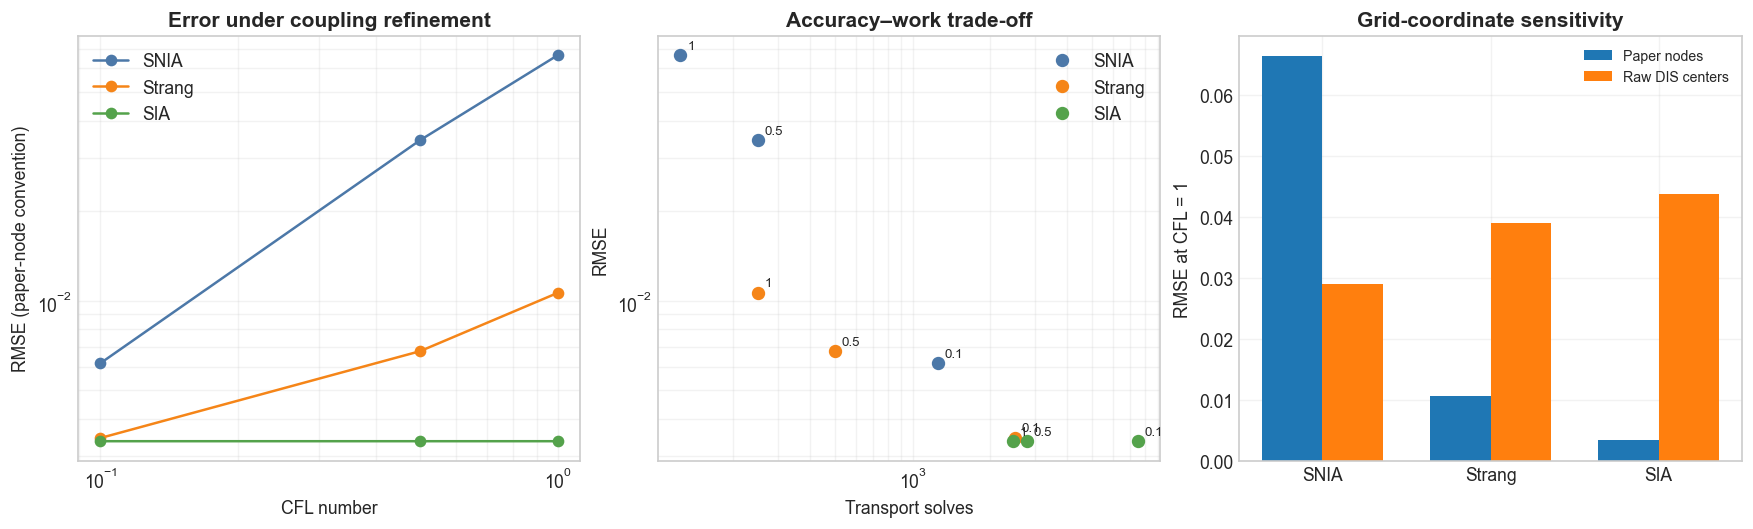

In [2]:
method_colors = {"SNIA": "#4c78a8", "Strang": "#f58518", "SIA": "#54a24b"}
figure, axes = plt.subplots(1, 3, figsize=(14.5, 4.3), constrained_layout=True)
for method, group in metrics.groupby("method", sort=False):
    group = group.sort_values("cfl")
    axes[0].loglog(
        group["cfl"], group["paper_node_rmse"], "o-", color=method_colors[method], label=method
    )
axes[0].set(
    xlabel="CFL number",
    ylabel="RMSE (paper-node convention)",
    title="Error under coupling refinement",
)
axes[0].legend()
for method, group in metrics.groupby("method", sort=False):
    axes[1].loglog(
        group["transport_solves"],
        group["paper_node_rmse"],
        "o",
        ms=7,
        color=method_colors[method],
        label=method,
    )
    for row in group.itertuples():
        axes[1].annotate(
            f"{row.cfl:g}",
            (row.transport_solves, row.paper_node_rmse),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
        )
axes[1].set(xlabel="Transport solves", ylabel="RMSE", title="Accuracy–work trade-off")
axes[1].legend()
cfl_one = (
    metrics.loc[np.isclose(metrics["cfl"], 1.0)].set_index("method").loc[["SNIA", "Strang", "SIA"]]
)
positions = np.arange(3)
width = 0.36
axes[2].bar(positions - width / 2, cfl_one["paper_node_rmse"], width, label="Paper nodes")
axes[2].bar(positions + width / 2, cfl_one["cell_center_rmse"], width, label="Raw DIS centers")
axes[2].set_xticks(positions, cfl_one.index)
axes[2].set(ylabel="RMSE at CFL = 1", title="Grid-coordinate sensitivity")
axes[2].legend(fontsize=8.5)
for axis in axes:
    axis.grid(True, which="both", alpha=0.25)
plt.show()

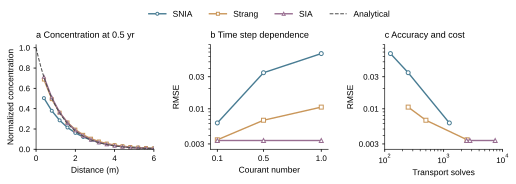

In [3]:
%config InlineBackend.figure_format = 'svg'
import matplotlib as mpl
from matplotlib.ticker import LogLocator

W = 183 / 25.4
COL = ["#477B92", "#C99659", "#986D91"]
mpl.rcdefaults()
mpl.rcParams.update(
    {
        "font.family": "Arial",
        "font.size": 9,
        "axes.titlesize": 9,
        "axes.labelsize": 8.5,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8.5,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
        "axes.linewidth": 0.65,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
        "savefig.facecolor": "white",
    }
)
with np.load(OUTPUT_DIR / "paper_figure6_data.npz", allow_pickle=False) as archive:
    D = {k: archive[k] for k in archive.files}
table = pd.read_csv(OUTPUT_DIR / "paper_figure6_metrics.csv", dtype=str).fillna("")
D["metrics"] = table.to_numpy(dtype=str)
D["metric_columns"] = np.array(table.columns)


def _manuscript_layout_03(fig):
    fig.canvas.draw()
    width_pt, height_pt = fig.get_size_inches() * 72
    offsets = [(0, 0), (0, 0), (0, 0)]
    for ax, (dx, dy) in zip(fig.axes, offsets, strict=True):
        pos = ax.get_position()
        ax.set_position([pos.x0 + dx / width_pt, pos.y0 - dy / height_pt, pos.width, pos.height])
    for legend in fig.legends:
        box = legend.get_bbox_to_anchor().transformed(fig.transFigure.inverted())
        legend.set_bbox_to_anchor(
            (box.x0 + 0 / width_pt, box.y0 - 4.5 / height_pt, box.width, box.height),
            transform=fig.transFigure,
        )


def save(n, fig, axes):
    _manuscript_layout_03(fig)
    plt.show()


def title(ax, letter, name):
    ax.set_title(f"{letter}  {name}", loc="left", pad=7, fontsize=9)


def grid(rows, cols, height, top=0.86, bottom=0.1, wspace=0.5, hspace=0.67):
    fig, axs = plt.subplots(rows, cols, figsize=(W, height), squeeze=False)
    fig.subplots_adjust(left=0.08, right=0.98, top=top, bottom=bottom, wspace=wspace, hspace=hspace)
    return (fig, list(axs.flat))


def fig3():
    d = D
    m = d["metrics"]
    names = list(d["metric_columns"])
    fig, axs = grid(1, 3, 2.8, top=0.77, bottom=0.25, wspace=0.48)
    for method, c, marker in zip(["SNIA", "Strang", "SIA"], COL, ["o", "s", "^"], strict=False):
        axs[0].plot(
            d["x_paper_nodes_m"],
            d[f"profile__{method}__cfl_1"],
            color=c,
            marker=marker,
            ms=3,
            mfc="white",
            lw=1.4,
            label=method,
        )
        records = m[m[:, names.index("method")] == method]
        cfl = records[:, names.index("cfl")].astype(float)
        order = np.argsort(cfl)
        error = records[:, names.index("paper_node_rmse")].astype(float)[order]
        solves = records[:, names.index("transport_solves")].astype(float)[order]
        axs[1].plot(cfl[order], error, color=c, marker=marker, ms=4, mfc="white", lw=1.4)
        axs[2].plot(solves, error, color=c, marker=marker, ms=4, mfc="white", lw=1.4)
    axs[0].plot(
        d["x_analytical_dense_m"],
        d["analytical_dense"],
        color=".3",
        ls="--",
        lw=1,
        label="Analytical",
    )
    axs[0].set(
        xlim=(0, 6), ylim=(0, 1.03), xlabel="Distance (m)", ylabel="Normalized concentration"
    )
    axs[1].set(
        xlim=(0.04, 1.06),
        xticks=[0.1, 0.5, 1],
        xlabel="Courant number",
        ylabel="RMSE",
        yscale="log",
    )
    axs[2].set(
        xlim=(100, 10000), xlabel="Transport solves", ylabel="RMSE", xscale="log", yscale="log"
    )
    axs[2].xaxis.set_major_locator(LogLocator(base=10, numticks=3))
    for a in axs[1:]:
        a.set_ylim(0.0025, 0.09)
        a.set_yticks([0.003, 0.01, 0.03])
        a.set_yticklabels(["0.003", "0.01", "0.03"])
        a.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())
    for a, letter, t in zip(
        axs,
        "abc",
        ["Concentration at 0.5 yr", "Time step dependence", "Accuracy and cost"],
        strict=False,
    ):
        title(a, letter, t)
    fig.legend(
        *axs[0].get_legend_handles_labels(), ncol=4, loc="upper center", bbox_to_anchor=(0.53, 1)
    )
    save(3, fig, axs)


fig3()